<a href="https://colab.research.google.com/github/nannastahl/CB2330-project/blob/main/F%C3%B6rslag_kod_number_of_contacts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

theta = 0.85
Mean simulated contacts: 35.622
Expected contacts: 35.699999999999996


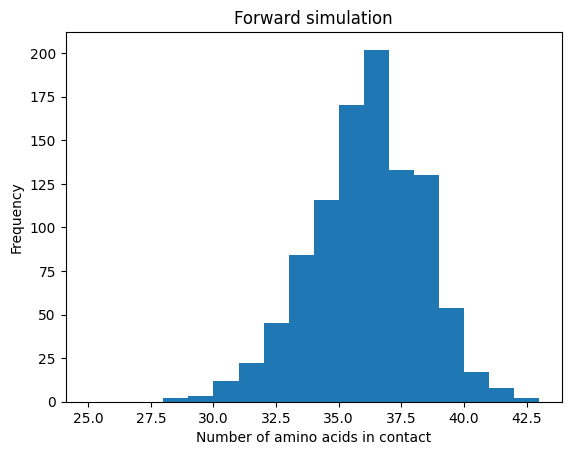

True theta: 0.85
Simulated observation: 34
Acceptance rate: 0.2834
Estimated theta: 0.7753316940657634 +/- 0.07446250497459858


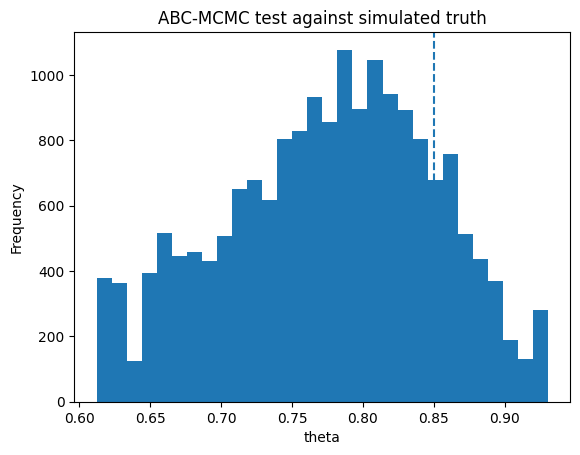

Observed contacts: 36
Acceptance rate: 0.33185
Estimated theta: 0.8315930037504983 +/- 0.060087949915401055


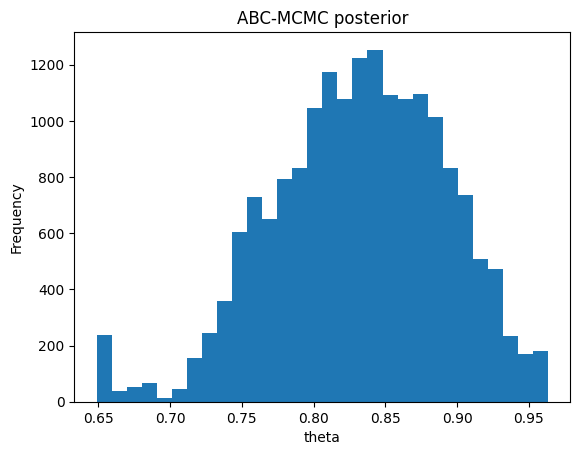

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N_RESIDUES = 42
x_obs = 36 #36 of 42 amino acids in contact with DOPS membrane at pH 7

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32

seed = 30


def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m


def simulation(theta, state, n_residues=N_RESIDUES):
    contacts = 0

    for i in range(n_residues):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        rs = state / M_LCG #Random number between 0 and 1

        if rs < theta: #Amino acid is in contact with membrane
            contacts += 1

    return contacts, state


#Forward simulation

theta = 0.85
n_simulations = 1000
simulated_contacts = [0] * n_simulations

state = seed

for i in range(n_simulations):
    simulated_contacts[i], state = simulation(theta, state)

print("theta =", theta)
print("Mean simulated contacts:", np.mean(simulated_contacts))
print("Expected contacts:", N_RESIDUES * theta)

plt.hist(simulated_contacts, bins=range(25, 44))
plt.xlabel("Number of amino acids in contact")
plt.ylabel("Frequency")
plt.title("Forward simulation")
plt.show()


def summary(x):
    return x

PRIOR = (0.0, 1.0)


def abc_mcmc(n_steps, epsilon, start, state, x_obs, half_width=0.03):

    theta = start
    chain = [0.0] * n_steps
    n_acc = 0

    for t in range(n_steps):

        #Propose new theta close to current theta
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        prop = theta + half_width * (2 * state / M_LCG - 1)

        #Only use theta values inside prior
        if PRIOR[0] <= prop <= PRIOR[1]:

            x_sim, state = simulation(prop, state)

            #Accept if simulated number of contacts is close enough to observed
            if abs(summary(x_sim) - summary(x_obs)) <= epsilon:
                theta = prop
                n_acc += 1

        chain[t] = theta

    return chain, n_acc, state


#Test against simulated truth
THETA_TRUE = 0.85

state = seed
x_test, state = simulation(THETA_TRUE, state)

print("True theta:", THETA_TRUE)
print("Simulated observation:", x_test)

chain_test, n_acc_test, state = abc_mcmc(
    n_steps=20000,
    epsilon=1,
    start=0.8,
    state=state,
    x_obs=x_test)

burn_in = 2000 #Saw on yt ypu should use a burn in, don't know if necessary
posterior_test = chain_test[burn_in:]

print("Acceptance rate:", n_acc_test / len(chain_test))
print("Estimated theta:", np.mean(posterior_test), "+/-", np.std(posterior_test))


plt.hist(posterior_test, bins=30)
plt.axvline(THETA_TRUE, linestyle="--")
plt.xlabel("theta")
plt.ylabel("Frequency")
plt.title("ABC-MCMC test against simulated truth")
plt.show()


#Estimate theta from paper result

state = seed

chain, n_acc, state = abc_mcmc(
    n_steps=20000,
    epsilon=1,
    start=0.8,
    state=state,
    x_obs=x_obs
)

posterior = chain[burn_in:]

print("Observed contacts:", x_obs)
print("Acceptance rate:", n_acc / len(chain))
print("Estimated theta:", np.mean(posterior), "+/-", np.std(posterior))


plt.hist(posterior, bins=30)
plt.xlabel("theta")
plt.ylabel("Frequency")
plt.title("ABC-MCMC posterior")
plt.show()


#Assumptions:
#Each amino acid is either in contact or not in contact with the membrane.
#Each amino acid has the same probability theta of being in contact.
#Contacts between amino acids are independent.
#The observed 36 contacts are treated as one observation from this process.
#Residue identity, charge and position are not included in the model.